# Image analysis and pattern recognition - Final Project 

**Group ID:** 24

**Author 1 (341742):** Axel CEBILLE  
**Author 2 (345815):** Melissa RIESEN  
**Author 3 (347320):** Sophie MOSEGAARD  

**Challenge:** Classic


In [29]:
import os
import cv2
import numpy as np
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
from glob import glob
import pandas as pd
from collections import defaultdict
import itertools
import csv
import itertools
import sys
sys.path.append('.')


### Pipeline overview

The fist step in processing the data was to manually label the chocolates in the refernce and training images to create annotations that could be used in subsequent processing steps.  
We used [roboflow](https://roboflow.com/), a online tool that allowed us to draw bounding boxes around the chocolates and label them. The annotation data is stored a csv file named [ _annotations.csv ](data/_annotations.csv) where each row represents a single bounding box around an object in an image. The columns include:

- **filename** - name of the image
- **width,height** - number of pixel in image
- **class** - class of the object within the box
- **xmin,ymin,xmax,ymax** - coordinates specification of the bounding box

This step was also done for all other objects and prominent background contours in the training images, as recorded in the [ _annotations_objects.csv ](data/_annotations_objects.csv) file.


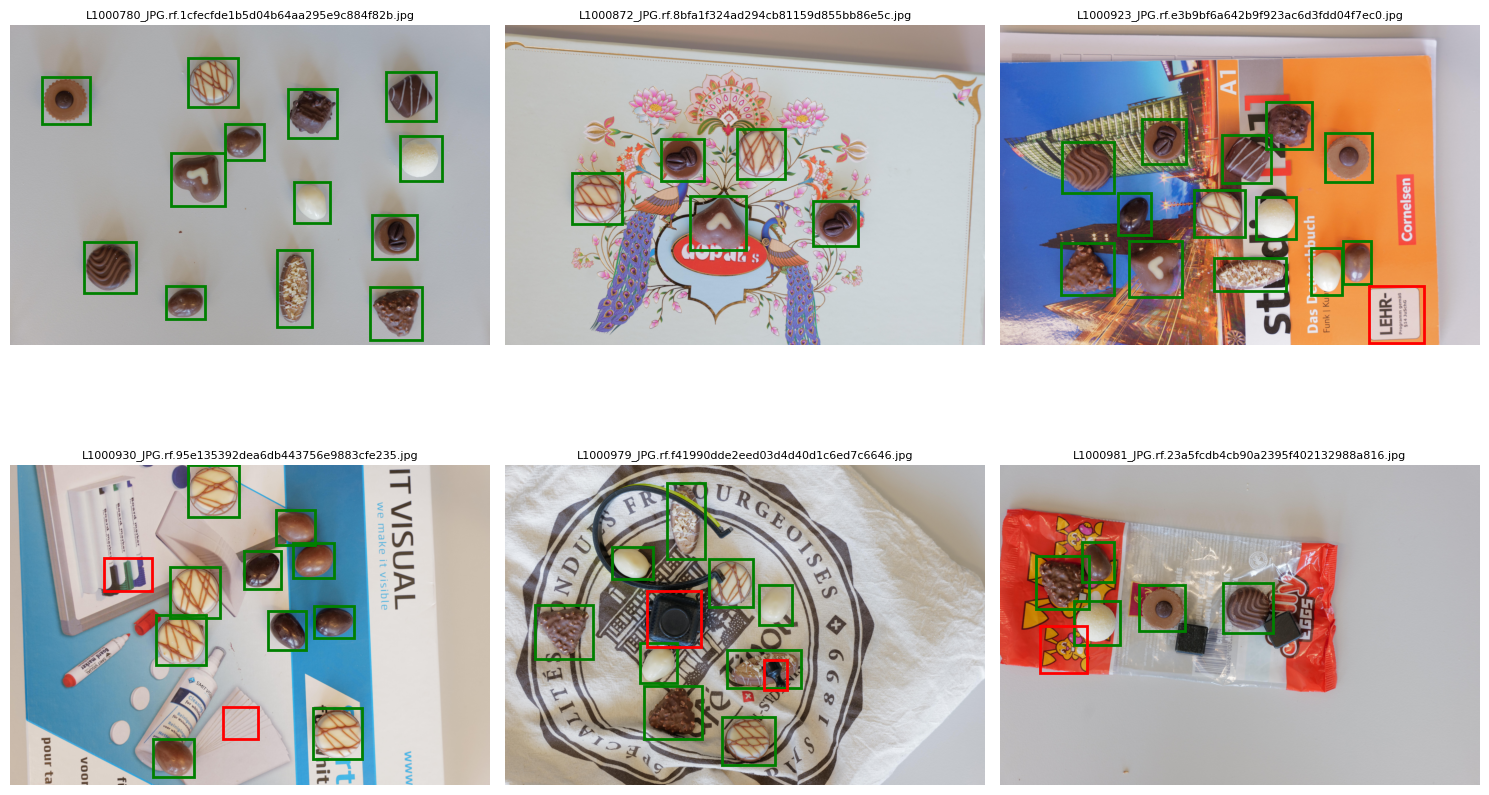

In [ ]:
from visualizations import show_bounding_boxes

# Paths relative to the notebook location (src/)
visualize_img = os.path.abspath(os.path.join('..', 'images', 'report_visualization'))
annot_choc = os.path.abspath(os.path.join('data', '_annotations.csv'))
annot_obj = os.path.abspath(os.path.join('data', '_annotations_objects.csv'))

show_bounding_boxes(visualize_img, annot_choc, annot_obj)


In the images above, green bounding boxes indicate labeled chocolates, while red boxes highlight examples of other object or prominent background elements that were annotated.

The images have high visual complexity due to highly different backgrounds and varying colors. We tried to reduce the complexity caused by different colors by using a K-mean clustering. For this we used the KMeans function from scikit-learn. To determine an appropriate value for k, we visually inspected the clustering results for different k values on a sample of images.

In [ ]:
def kmeans_clustering(image, k=4):
    Z = image.reshape((-1, 3))
    Z = np.float32(Z)
    kmeans = KMeans(n_clusters=k, random_state=0).fit(Z)
    labels = kmeans.labels_.reshape(image.shape[:2])
    clustered_img = kmeans.cluster_centers_[labels].reshape(image.shape).astype(np.uint8)
    return clustered_img, labels

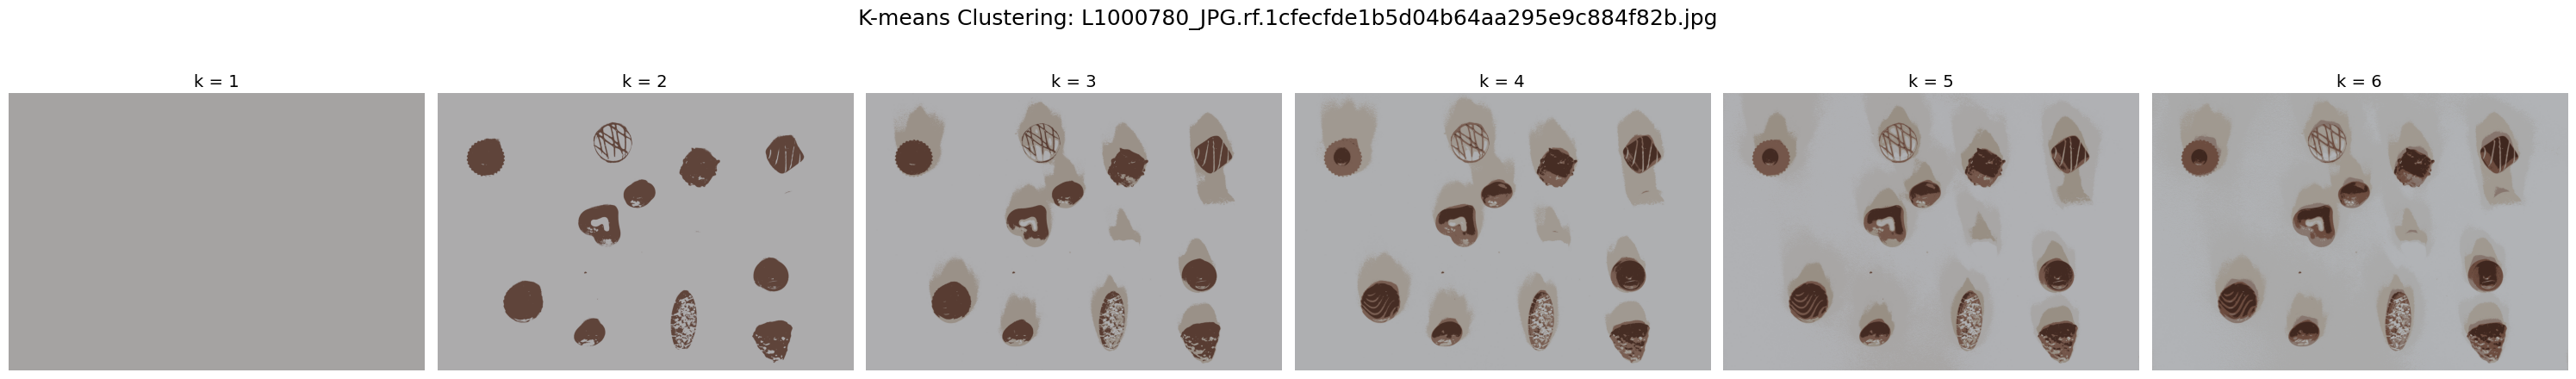

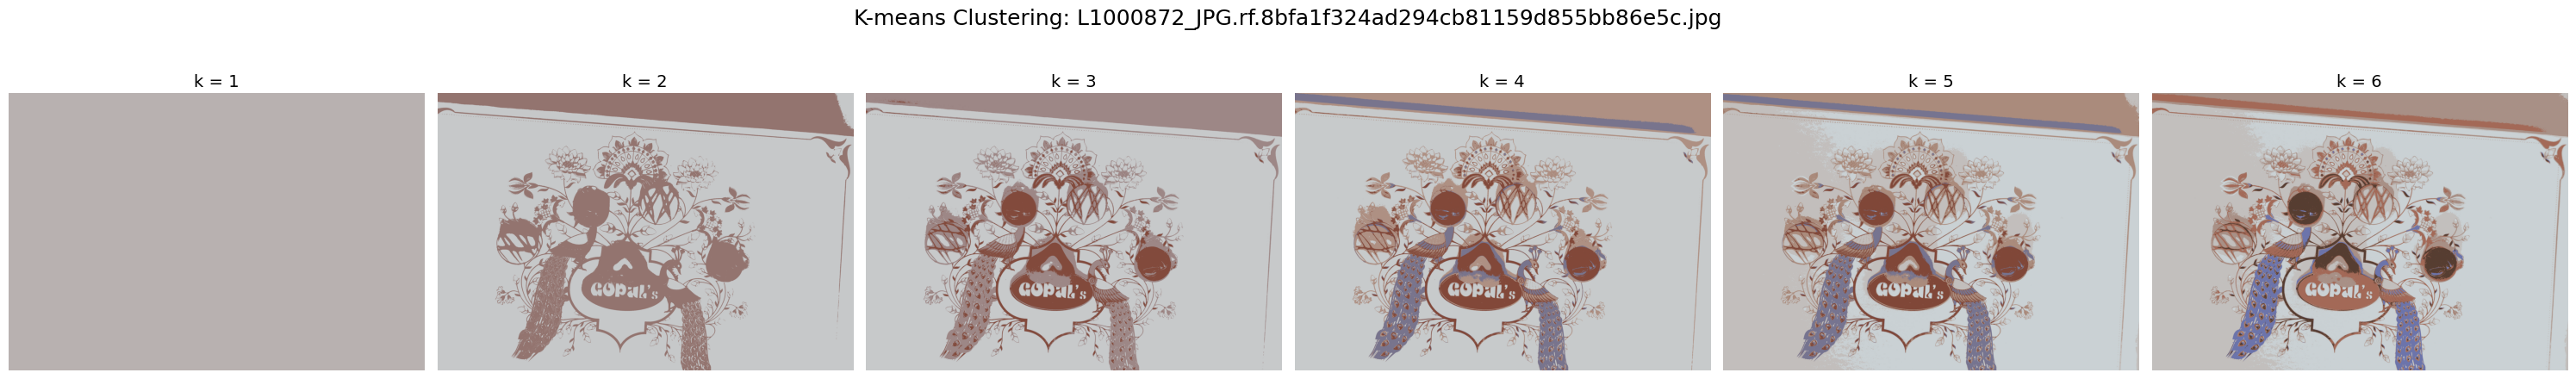

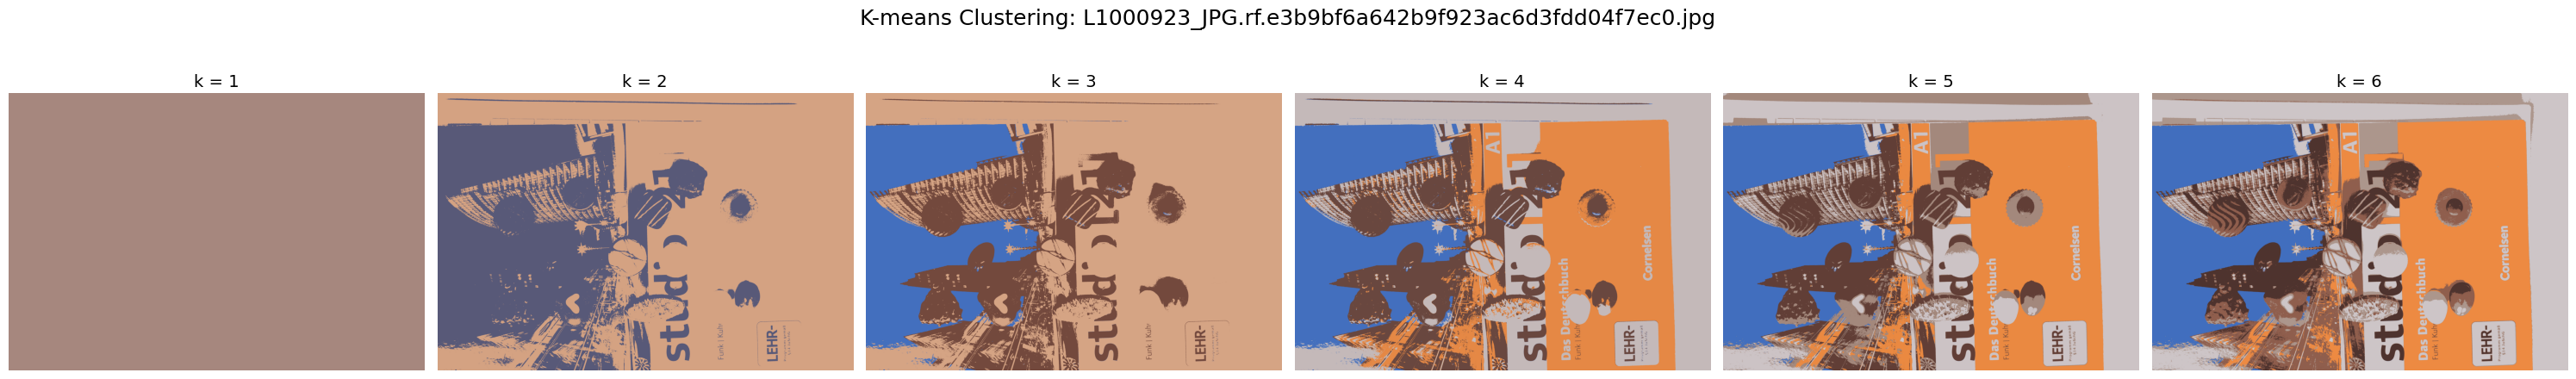

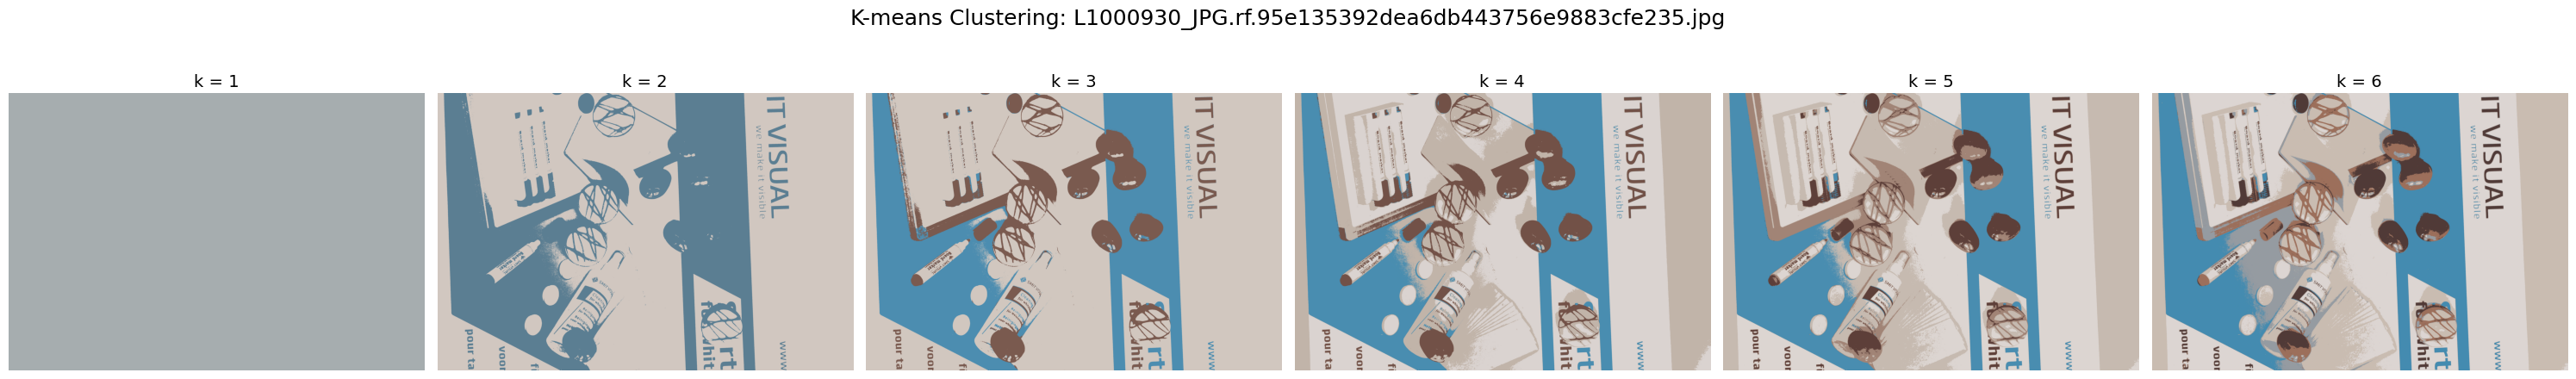

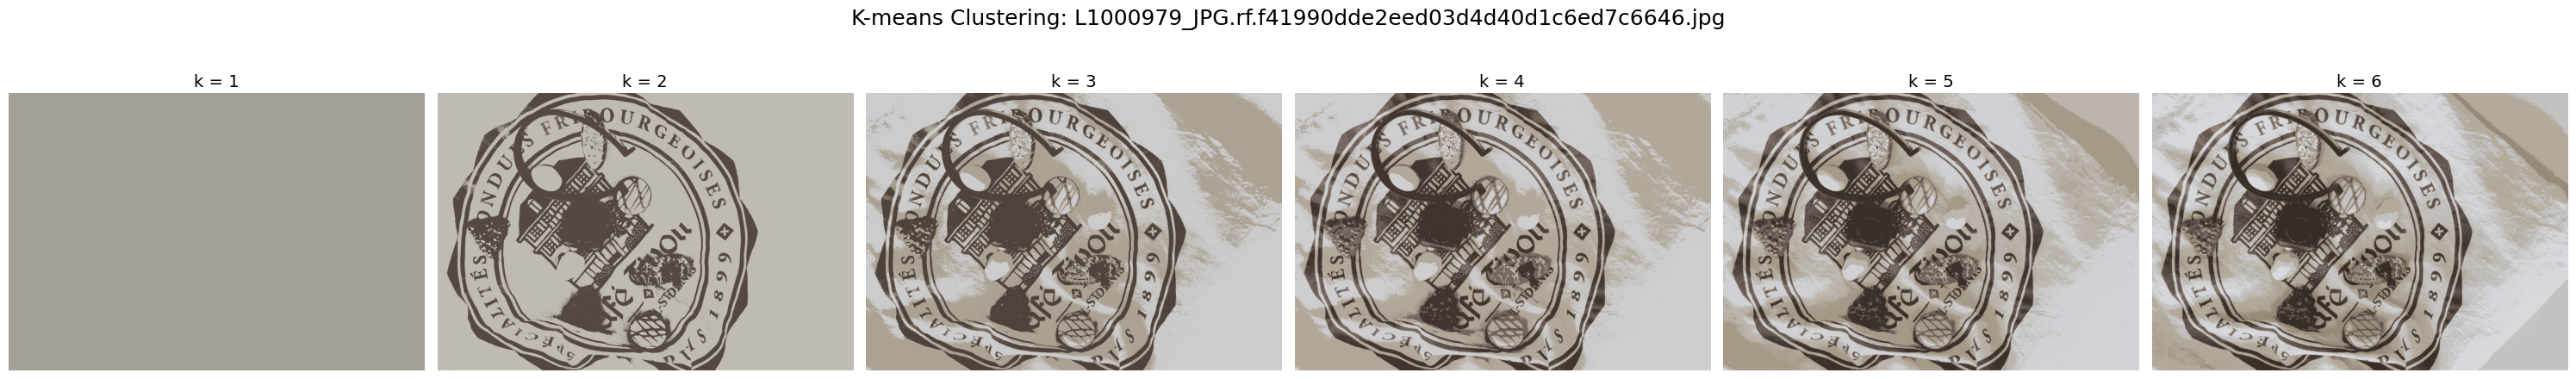

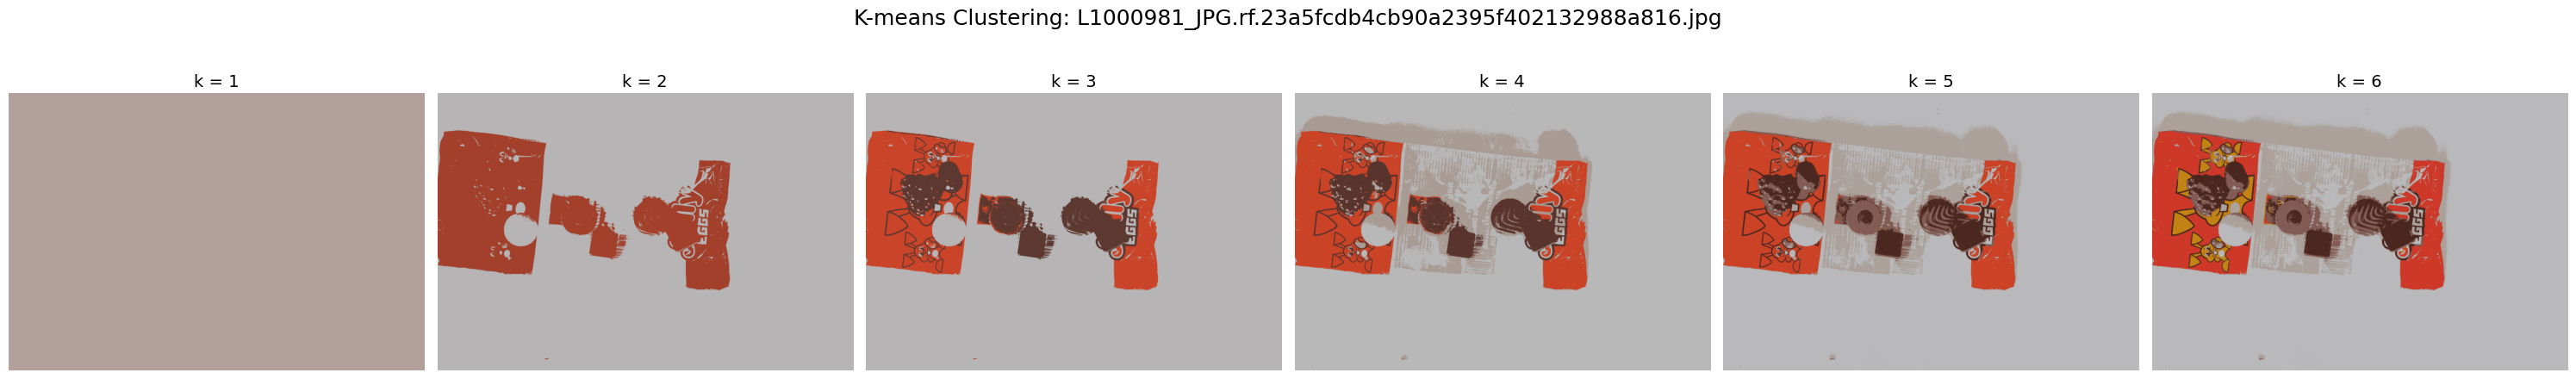

In [32]:
from visualizations import kmeans_comparisons
kmeans_comparisons(kmeans_clustering, visualize_img, 6)



From the images above we concluded that the appropriate value of k varies depending on the characteristics of the image. That means on images with a uniform whitish background, k = 3 is sufficient to separate chocolates from the background. For images with more complex or colorful backgrounds, increasing to k = 4 helps separate additional distracting elements. Using values higher than k = 4 tends to introduce unnecessary detail without improving the outcome.

The function `extract_class_mask` converts the clustered images, resulting from the K-meaning clustering, into a binary mask to identify object regions. These mask are passed to the `clean_mask` function where morphological cleaning is applied. This removes noise, fills holes, and enhances object boundaries. The cleaned mask are important to be able to create appropriate bounding boxes in the subsequential steps.

In [65]:
def extract_class_masks(labels, num_classes=4):
    masks = []
    for i in range(num_classes):
        mask = np.uint8(labels == i) * 255
        masks.append(mask)
    return masks

def clean_mask(mask):
    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))

    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel_close)
    
    # Optional: strengthen structure further
    dilated = cv2.dilate(closed, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)), iterations=1)
    return dilated

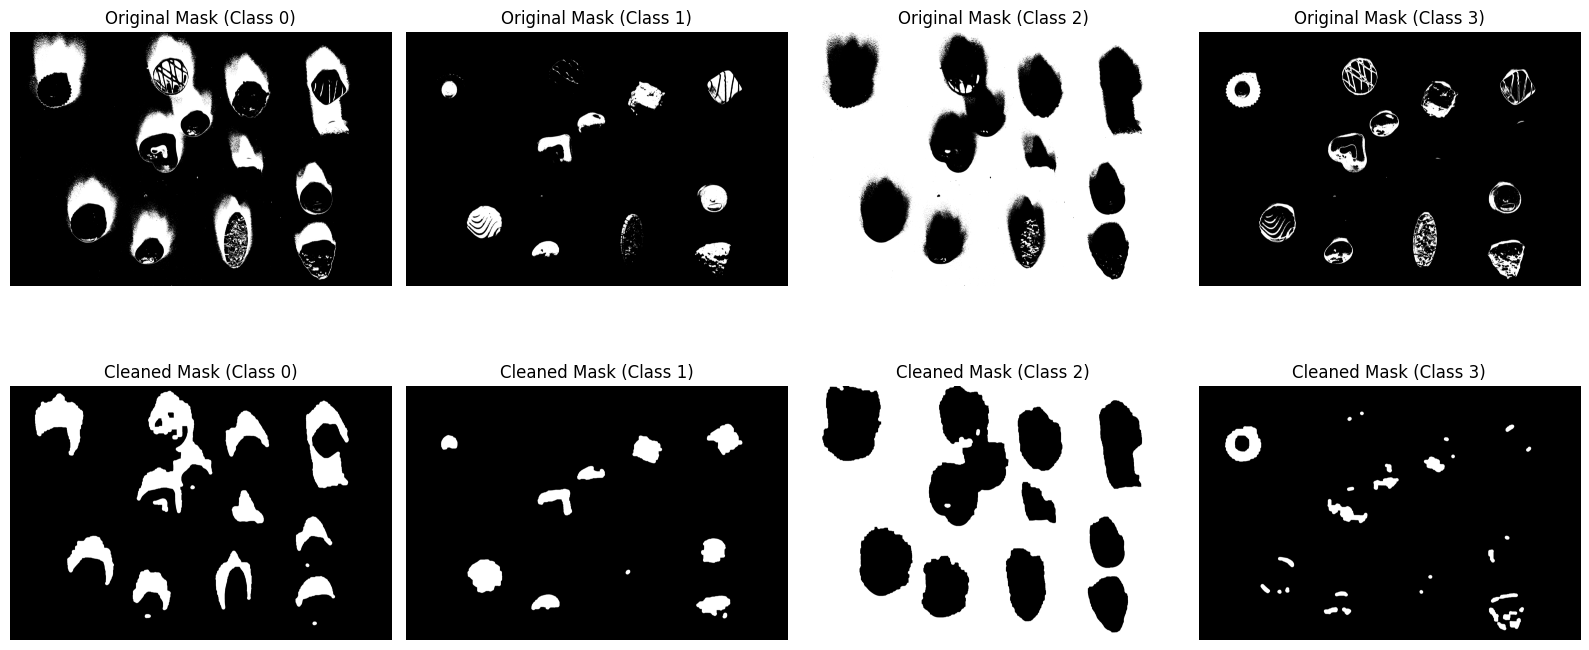

In [ ]:
from visualizations import visualize_all_mask_cleaning
vis_img = os.path.abspath(os.path.join('..', 'images', 'report_visualization\L1000780_JPG.rf.1cfecfde1b5d04b64aa295e9c884f82b.jpg'))
clustered_img, labels = kmeans_clustering(cv2.imread(vis_img))
mask_img = extract_class_masks(labels, num_classes=4)
visualize_all_mask_cleaning(mask_img)

In the image above, the transformation from raw segmentation to clean object masks is showed. To clearly illustrate the effects of morphological operations like opening and closing, we used relatively large structuring elements. However, this resulted in an aggressive transformation that was not suitable for precise further processing. In the final implementation, we used more moderate structuring elements. This helped us to get more appropriate masks for contour extraction and classification.

The `get_contours_from_mask`function extracts objects contours from a cleaned binary mask using `findContours`from the OpenCV library, which detects the outer boundaries of white regions. To eliminate noise and irrelevant regions, the function applies constraints on contour area and bounding box size, ensuring that only objects within a specified size range are retained. This helped us to avoid having way to small or too big bounding boxes.

In [57]:
def get_contours_from_mask(mask, min_area=1500, size_range=(350, 800)): #Change here 450 to 700
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filtered = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        if (min_area < cv2.contourArea(c) and
            size_range[0] <= w <= size_range[1] and
            size_range[0] <= h <= size_range[1]):
            filtered.append(c)
    return filtered

As a next step we built color-based feature representations of objects. `extract_histogram` extracts a color histogram from a detected object region, capturing the color distribution as a feature vector. `load_reference_histograms_from_contours` uses the reference images, segments them, detects object contours, and extracts finally a single representative histogram per class, building a reference data for later comparison. `load_reference_histograms_from_annotations` uses the labeld training data to extract object regions. It computes the average histograms for each class to generate more robust and representative color profiles.

In [58]:
def extract_histogram(img, contour):
    x, y, w, h = cv2.boundingRect(contour)
    roi = img[y:y+h, x:x+w]
    hist = cv2.calcHist([roi], [0, 1, 2], None, [8,8,8], [0,256,0,256,0,256])
    cv2.normalize(hist, hist)
    return hist.flatten()

def load_reference_histograms_from_contours(ref_folder):
    histograms = {}
    for path in glob(os.path.join(ref_folder, '*.jpg')):
        img = cv2.imread(path)
        clustered_img, labels = kmeans_clustering(img, k=4)
        masks = extract_class_masks(labels)
        for i, mask in enumerate(masks):
            cleaned = clean_mask(mask)
            contours = get_contours_from_mask(cleaned)
            if contours:
                hist = extract_histogram(img, contours[0])
                filename = os.path.basename(path)
                class_name = filename.split('_JPG')[0]
                histograms[class_name] = hist
                break
    return histograms

def load_reference_histograms_from_annotations(csv_path, train_folder):
    df = pd.read_csv(csv_path)

    # To store histograms per class
    histograms_by_class = defaultdict(list)

    for _, row in df.iterrows():
        filename = row['filename']
        img_path = os.path.join(train_folder, filename)
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Failed to load image {img_path}")
            continue

        x_min, y_min, x_max, y_max = int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax'])
        cls = row['class']

        # Crop region and extract histogram
        roi = img[y_min:y_max, x_min:x_max]
        if roi.size == 0:
            print(f"Warning: Empty ROI for {filename} {cls}")
            continue

        hist = cv2.calcHist([roi], [0, 1, 2], None, [8,8,8], [0,256,0,256,0,256])
        cv2.normalize(hist, hist)
        histograms_by_class[cls].append(hist.flatten())

    # Compute mean histogram per class
    mean_histograms = {}
    for cls, hist_list in histograms_by_class.items():
        mean_hist = np.mean(hist_list, axis=0)
        mean_histograms[cls] = mean_hist

    print(f"Computed histograms for {len(mean_histograms)} classes.")
    return mean_histograms

The `match_histogram`function compares the histogram from a detected object to two sets of reference histograms. 
- Comparing it to the averaged chocolate histograms
- Comparing it to non-target or background object histograms

It finds the best matching histogram, and only returns a corresponding label if it is a chocolate type.

In [59]:
def match_histogram(hist, ref_chocolates, ref_objects):
    best_label = None
    best_score = -1

    # Compare to chocolate reference histograms
    for label, ref_hist in ref_chocolates.items():
        score = cv2.compareHist(hist, ref_hist, cv2.HISTCMP_CORREL)
        if score > best_score:
            best_score = score
            best_label = label
            best_from = 'chocolate'

    # Compare to object reference histograms
    for label, ref_hist in ref_objects.items():
        score = cv2.compareHist(hist, ref_hist, cv2.HISTCMP_CORREL)
        if score > best_score:
            best_score = score
            best_label = label
            best_from = 'object'

    # Only return label if it matched a chocolate, not an object
    return best_label if best_from == 'chocolate' else None


The `compute_overlap_ratio`function calculates the overlap ratio between two bounding boxes. This overlap ratio we use in the `filter_overlapping_boxes`function to remove redundant or overlapping detections. The function uses confidence scores to resolve overlaps; if the overlap ration exceeds the defined threshold, it keeps only the box with the higher score and discards the one wit the lower score.

In [60]:
def compute_overlap_ratio(box1, box2):
    # (x, y, w, h)
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    # Convert to x_min, y_min, x_max, y_max
    xa1, ya1, xa2, ya2 = x1, y1, x1 + w1, y1 + h1
    xb1, yb1, xb2, yb2 = x2, y2, x2 + w2, y2 + h2

    # Compute intersection
    xi1 = max(xa1, xb1)
    yi1 = max(ya1, yb1)
    xi2 = min(xa2, xb2)
    yi2 = min(ya2, yb2)

    iw = max(0, xi2 - xi1)
    ih = max(0, yi2 - yi1)
    inter_area = iw * ih

    area1 = w1 * h1
    area2 = w2 * h2
    overlap_ratio = inter_area / min(area1, area2) if min(area1, area2) > 0 else 0


    return overlap_ratio

def filter_overlapping_boxes(detections, overlap_thresh=0.1):
    keep = [True] * len(detections)

    for i, j in itertools.combinations(range(len(detections)), 2):
        if not keep[i] or not keep[j]:
            continue

        boxA = detections[i]['bbox']
        boxB = detections[j]['bbox']
        overlap = compute_overlap_ratio(boxA, boxB)

        if overlap >= overlap_thresh:
            # Compare scores
            if detections[i]['score'] >= detections[j]['score']:
                keep[j] = False
            else:
                keep[i] = False

    return [det for k, det in enumerate(detections) if keep[k]]




In [63]:
from visualizations import display_results
import itertools

def process_image(img_path, reference_histograms, reference_histograms_objects, k=4, overlap=True):
    img = cv2.imread(img_path)
    clustered_img, labels = kmeans_clustering(img, k)
    class_masks = extract_class_masks(labels, k)

    all_contours = []
    all_labels = []
    choc_contours = []
    choc_labels = []
    no_over_choc_contours = []
    no_over_choc_labels = []

    chocolate_detections = []

    for mask in class_masks:
        cleaned = clean_mask(mask)
        contours = get_contours_from_mask(cleaned)
        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            roi = img[y:y+h, x:x+w]
            if roi.size == 0:
                continue

            hist = extract_histogram(img, cnt)
            best_label = match_histogram(hist, reference_histograms, reference_histograms_objects)
            
            all_contours.append(cnt)
            all_labels.append(best_label)

            if best_label:  # Assume non-empty label means chocolate
                choc_contours.append(cnt)
                choc_labels.append(best_label)

                score = cv2.compareHist(hist, reference_histograms[best_label], cv2.HISTCMP_CORREL)
                chocolate_detections.append({
                    'contour': cnt,
                    'label': best_label,
                    'score': score,
                    'bbox': (x, y, w, h)
                })

    # Overlap filtering on chocolate detections
    if overlap:
        filtered = filter_overlapping_boxes(chocolate_detections, overlap_thresh=0.1)
    else:
        filtered = chocolate_detections

    for d in filtered:
        no_over_choc_contours.append(d['contour'])
        no_over_choc_labels.append(d['label'])

    # Display
    display_results(img, clustered_img, all_contours, all_labels, no_over_choc_contours, no_over_choc_labels)

In [62]:
total_train_img = os.path.abspath(os.path.join('..', 'images', 'train_total'))
ref_histograms = load_reference_histograms_from_annotations(annot_choc, total_train_img)
obj_histograms = load_reference_histograms_from_annotations(annot_obj, total_train_img)

Computed histograms for 13 classes.
Computed histograms for 34 classes.


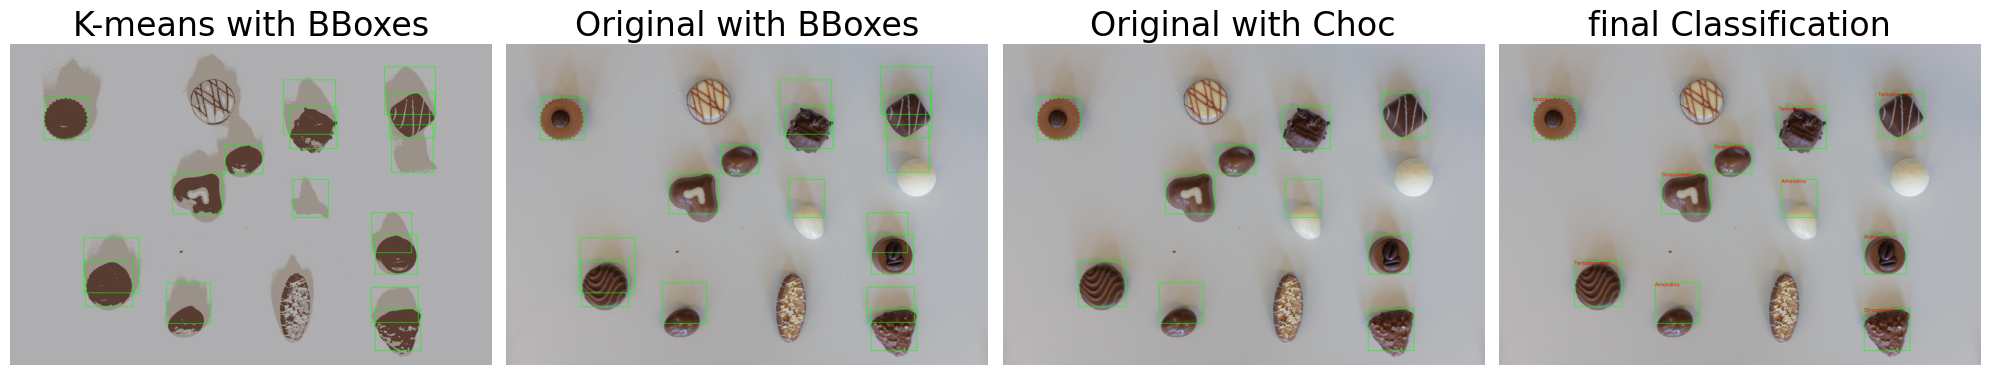

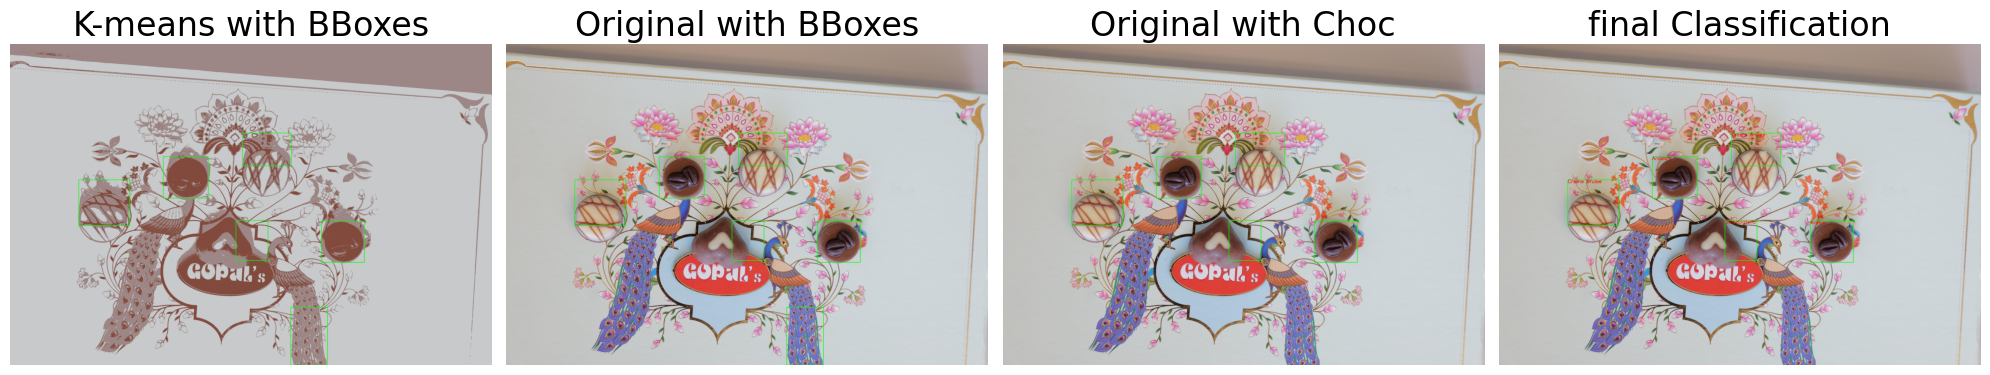

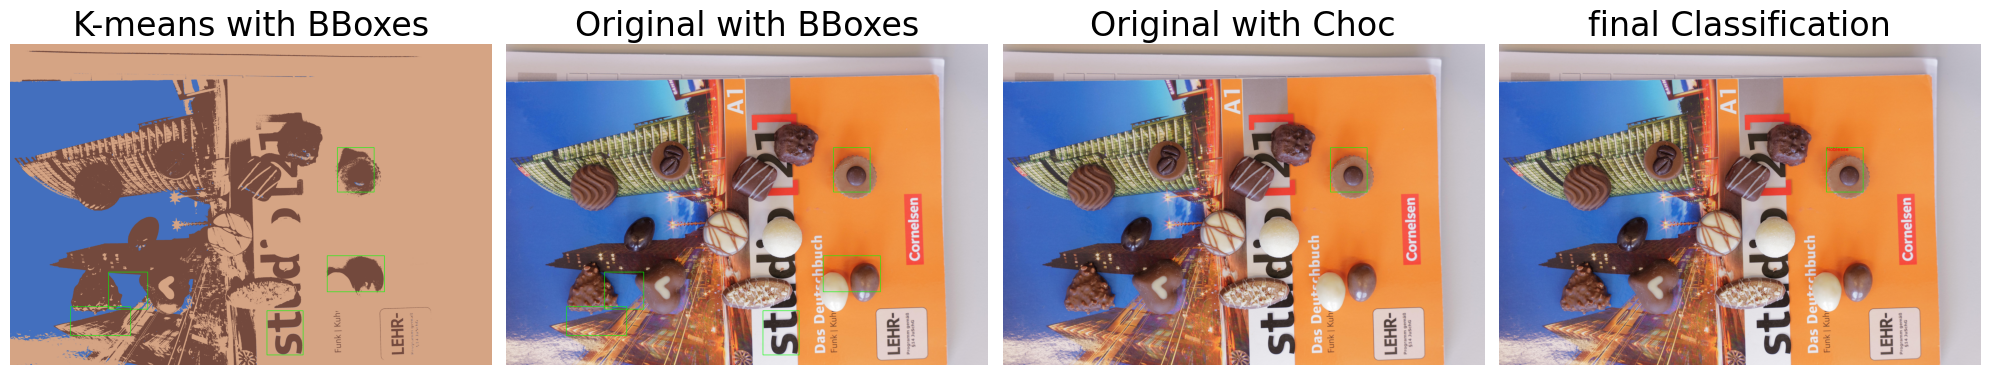

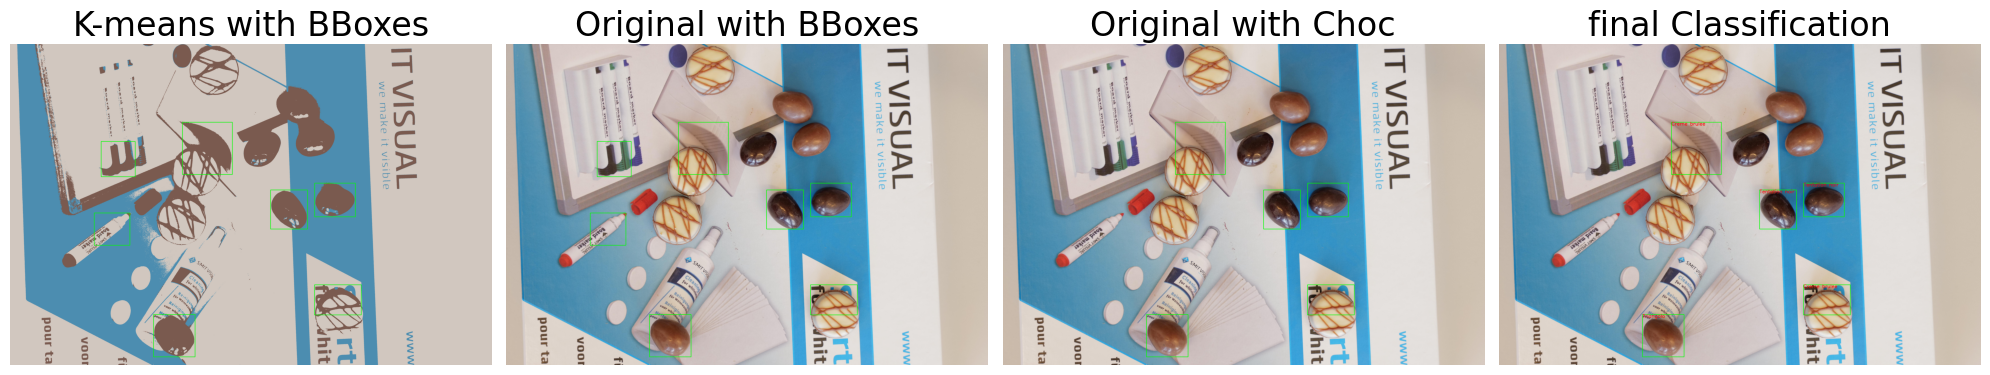

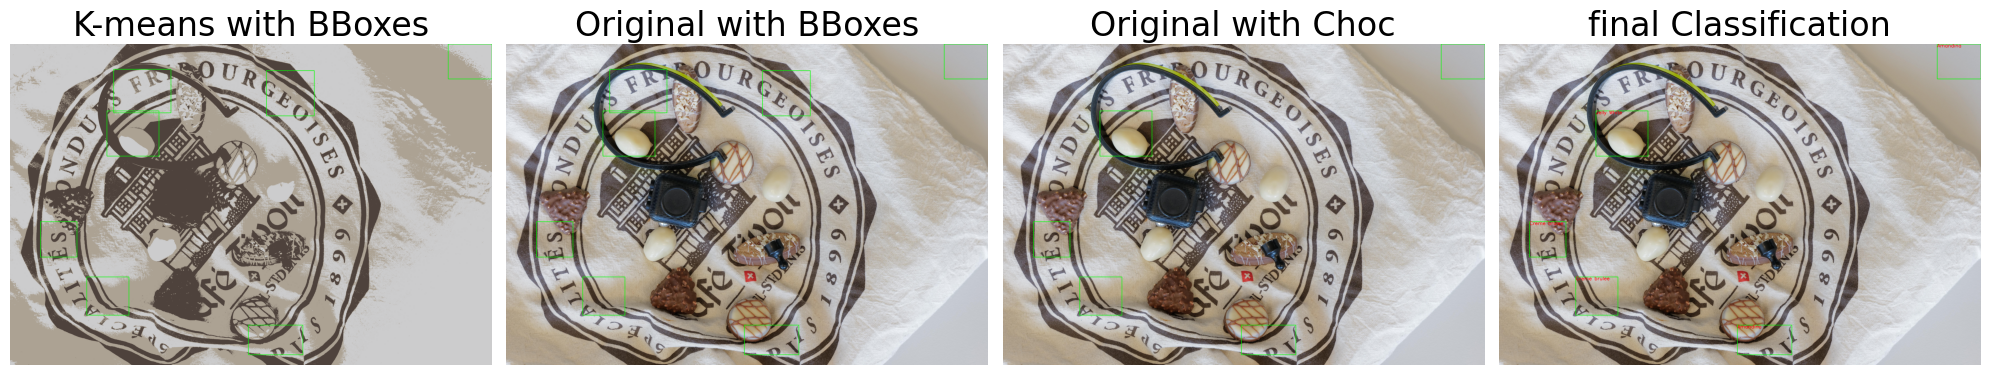

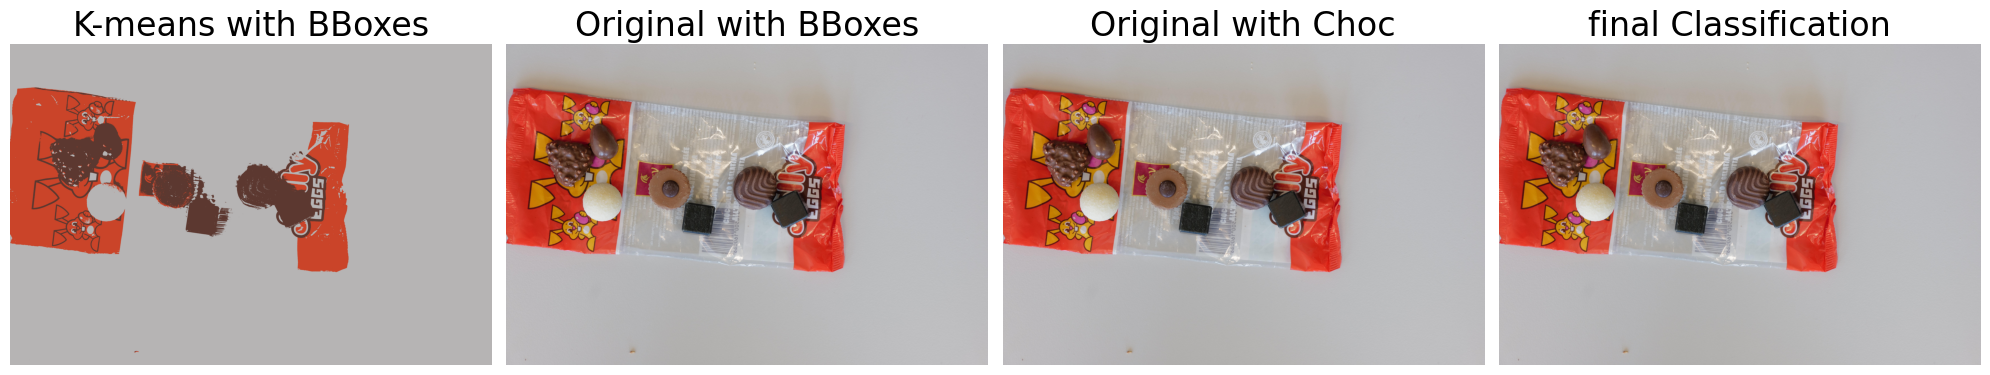

In [64]:
for img_path in glob(os.path.join(visualize_img, "*.jpg")):
    process_image(img_path, ref_histograms, obj_histograms, 3)

There are several bouding boxes that are overlapping. We need to remove the duplicates. For this we will look at the certainity with which the bounding box was assigned to its corresponding label. For bounding boxes ovelapping more than 10% of their area, we will keep the one with the highest certainity.

In [41]:
def compute_overlap_ratio(box1, box2):
    # (x, y, w, h)
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    # Convert to x_min, y_min, x_max, y_max
    xa1, ya1, xa2, ya2 = x1, y1, x1 + w1, y1 + h1
    xb1, yb1, xb2, yb2 = x2, y2, x2 + w2, y2 + h2

    # Compute intersection
    xi1 = max(xa1, xb1)
    yi1 = max(ya1, yb1)
    xi2 = min(xa2, xb2)
    yi2 = min(ya2, yb2)

    iw = max(0, xi2 - xi1)
    ih = max(0, yi2 - yi1)
    inter_area = iw * ih

    area1 = w1 * h1
    area2 = w2 * h2
    overlap_ratio = inter_area / min(area1, area2) if min(area1, area2) > 0 else 0

    return overlap_ratio

def filter_overlapping_boxes(detections, overlap_thresh=0.1):
    keep = [True] * len(detections)

    for i, j in itertools.combinations(range(len(detections)), 2):
        if not keep[i] or not keep[j]:
            continue

        boxA = detections[i]['bbox']
        boxB = detections[j]['bbox']
        overlap = compute_overlap_ratio(boxA, boxB)

        if overlap >= overlap_thresh:
            # Compare scores
            if detections[i]['score'] >= detections[j]['score']:
                keep[j] = False
            else:
                keep[i] = False

    return [det for k, det in enumerate(detections) if keep[k]]


